In [8]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, confusion_matrix

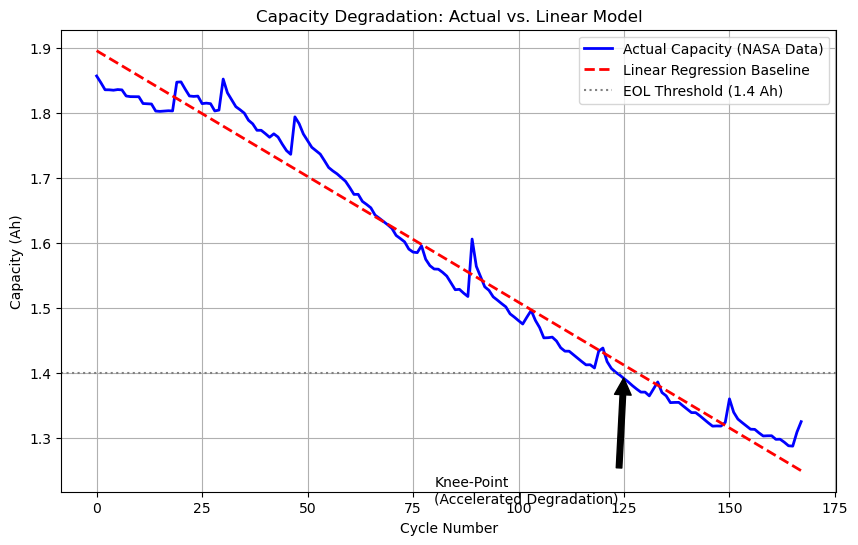

In [3]:
#Figure 1. Capacity Degradation curve for Battery B0005 in the NASA dataset, showing the non-linear “Knee-Point” and failure of the linear baseline
# 1. Filter for B0005 discharge cycles
df = pd.read_csv('metadata.csv')
df_b0005 = df[(df['battery_id'] == 'B0005') & (df['type'] == 'discharge')].copy()
df_b0005['Capacity'] = pd.to_numeric(df_b0005['Capacity'], errors='coerce')
df_b0005 = df_b0005.dropna(subset=['Capacity']).reset_index(drop=True)

# 2. Fit a Linear Regression Line
x = np.arange(len(df_b0005))
y = df_b0005['Capacity']
coefficients = np.polyfit(x, y, 1)
linear_fit = np.polyval(coefficients, x)

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', label='Actual Capacity (NASA Data)', linewidth=2)
plt.plot(x, linear_fit, 'r--', label='Linear Regression Baseline', linewidth=2)
plt.axhline(y=1.4, color='gray', linestyle=':', label='EOL Threshold (1.4 Ah)')

# 4. Annotate the Knee-Point
plt.annotate('Knee-Point\n(Accelerated Degradation)', xy=(125, 1.4), xytext=(80, 1.2),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Capacity Degradation: Actual vs. Linear Model')
plt.xlabel('Cycle Number')
plt.ylabel('Capacity (Ah)')
plt.legend()
plt.grid(True)
plt.savefig('knee_point_analysis.png')

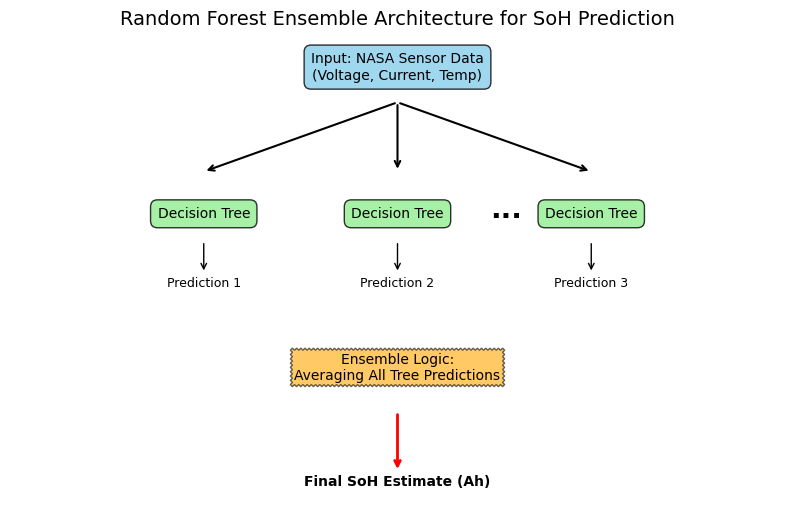

In [5]:
#Figure 2 . Architecture of the Random Forest Classifier for SoH Estimation

def draw_rf_flowchart():
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.axis('off')

    # Styles
    box_style = dict(boxstyle="round,pad=0.5", facecolor="skyblue", edgecolor="black", alpha=0.8)
    leaf_style = dict(boxstyle="round,pad=0.5", facecolor="lightgreen", edgecolor="black", alpha=0.8)

    # 1. Input Box
    ax.text(50, 90, "Input: NASA Sensor Data\n(Voltage, Current, Temp)", ha='center', bbox=box_style)
    
    # 2. Arrows to Trees
    for x in [25, 50, 75]:
        ax.annotate("", xy=(x, 70), xytext=(50, 85), arrowprops=dict(arrowstyle="->", lw=1.5))
        ax.text(x, 60, f"Decision Tree", ha='center', bbox=leaf_style)
        ax.text(x, 45, f"Prediction {x//25}", ha='center', fontsize=9)
        ax.annotate("", xy=(x, 48), xytext=(x, 55), arrowprops=dict(arrowstyle="->"))

    # 3. Dots for "N" trees
    ax.text(62, 60, "...", fontsize=20, fontweight='bold')

    # 4. Aggregation Box
    ax.text(50, 25, "Ensemble Logic:\nAveraging All Tree Predictions", ha='center', 
            bbox=dict(boxstyle="sawtooth", facecolor="orange", alpha=0.6))
    
    # 5. Final Output
    ax.annotate("", xy=(50, 5), xytext=(50, 18), arrowprops=dict(arrowstyle="->", lw=2, color='red'))
    ax.text(50, 2, "Final SoH Estimate (Ah)", ha='center', fontweight='bold')

    plt.title("Random Forest Ensemble Architecture for SoH Prediction", fontsize=14)
    plt.savefig('random_forest_flowchart.png', dpi=300)
    plt.show()
draw_rf_flowchart()

In [4]:
#extrcating my data for Battery B0005
#and save all required features (tempreature,time,uid,capacity) for just Battery B0005 in NEW CSV file called B0005_Full_Raw_Dataset.csv
metadata = pd.read_csv('metadata.csv')

# 2. Filter for Battery B0005 Discharge cycles only
# This identifies the 168 files that belong to your battery
b0005_files = metadata[(metadata['battery_id'] == 'B0005') & (metadata['type'] == 'discharge')]

# 3. The "Master Table" Loop
all_cycles_list = []

print(f"Searching for {len(b0005_files)} cycle files...")

for index, row in b0005_files.iterrows():
    filename = row['filename']
    uid = row['uid']
    capacity = row['Capacity']
    
    # Logic: Only process if the file exists in my folder
    if os.path.exists(filename):
        # Load raw sensor data
        cycle_df = pd.read_csv(filename)
        
        # Create a table for THIS cycle
        temp_df = pd.DataFrame({
            'uid': [uid] * len(cycle_df), # Repeat the ID for the whole cycle
            'Time': cycle_df['Time'],      # Raw time steps
            'Temperature_measured': cycle_df['Temperature_measured'], # Raw temp
            'Capacity': [capacity] * len(cycle_df) # Link the Capacity label
        })
        
        all_cycles_list.append(temp_df)

# 4. Merge everything into 1 Table CSV file (B0005_Full_Raw_Dataset.csv)
if all_cycles_list:
    final_table = pd.concat(all_cycles_list, ignore_index=True)
    print("Success! Master Table Created.")
    print(final_table.head()) # Shows the first 5 rows
    final_table.to_csv('B0005_Full_Raw_Dataset.csv', index=False)
else:
    print("No files found. Ensure the CSV files are in the same folder as this script.")

Searching for 168 cycle files...
Success! Master Table Created.
    uid    Time  Temperature_measured            Capacity
0  5122   0.000             24.330034  1.8564874208181574
1  5122  16.781             24.325993  1.8564874208181574
2  5122  35.703             24.389085  1.8564874208181574
3  5122  53.781             24.544752  1.8564874208181574
4  5122  71.922             24.731385  1.8564874208181574


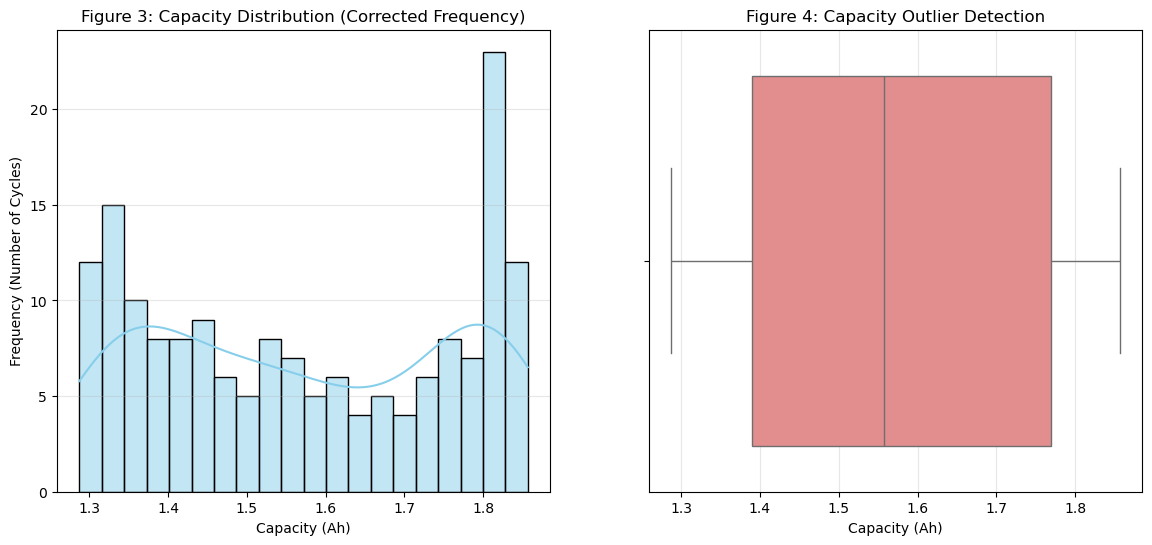

In [5]:
#Visaulising my data 
# 1. define dataframe 
df = pd.read_csv('B0005_Full_Raw_Dataset.csv')

# 2. extract unique cycles for Capacity visualization
# This ensures we count each of the 168 test sessions exactly once.
unique_cycles = df.drop_duplicates(subset=['uid'])

# 3. Create the Visualization Layout
plt.figure(figsize=(14, 6))

#Fig. 3. Histogram of Raw Capacity Distribution (Battery B0005)
# --- HISTOGRAM --
plt.subplot(1, 2, 1)
sns.histplot(unique_cycles['Capacity'], kde=True, color='skyblue', bins=20)
plt.title('Figure 3: Capacity Distribution (Corrected Frequency)')
plt.xlabel('Capacity (Ah)')
plt.ylabel('Frequency (Number of Cycles)')
plt.grid(axis='y', alpha=0.3)

#Fig. 4. Boxplot Examination of Outlier Identification (Battery B0005)
# ---  BOXPLOT ---
plt.subplot(1, 2, 2)
sns.boxplot(x=unique_cycles['Capacity'], color='lightcoral', fliersize=5)
plt.title('Figure 4: Capacity Outlier Detection')
plt.xlabel('Capacity (Ah)')
plt.grid(axis='x', alpha=0.3)

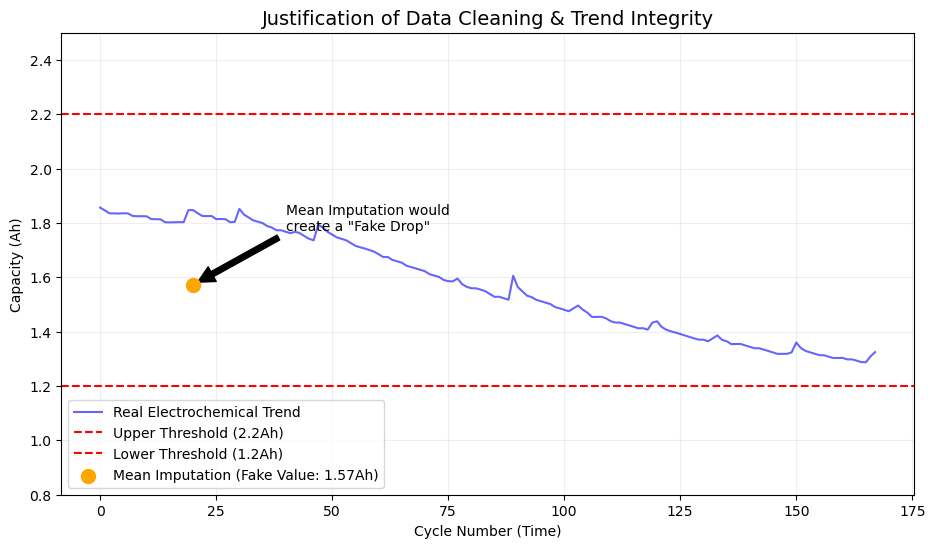

In [14]:
#Figure 5 :Technical Justification for Data Cleaning and Rejection of Mean Imputation
# 1. Setup Data
df = pd.read_csv('metadata.csv')
b0005 = df[(df['battery_id'] == 'B0005') & (df['type'] == 'discharge')].copy()
b0005['Capacity'] = pd.to_numeric(b0005['Capacity'], errors='coerce')
b0005 = b0005.sort_values('test_id').reset_index(drop=True)

# 2. Create a "Fake" Missing Value Scenario for Illustration
mean_val = b0005['Capacity'].mean()
missing_idx = 20  # A point early in the battery life
real_val = b0005.loc[missing_idx, 'Capacity']

# 3. Plotting
plt.figure(figsize=(11, 6))

# Plot the real treand
plt.plot(b0005.index, b0005['Capacity'], 'b-', label='Real Electrochemical Trend', alpha=0.6)

# Highlight the Outlier Thresholds you mentioned (1.2Ah and 2.2Ah)
plt.axhline(y=2.2, color='red', linestyle='--', label='Upper Threshold (2.2Ah)')
plt.axhline(y=1.2, color='red', linestyle='--', label='Lower Threshold (1.2Ah)')

# Illustrate why Mean Imputation is bad
plt.scatter(missing_idx, mean_val, color='orange', s=100, zorder=5, 
            label=f'Mean Imputation (Fake Value: {mean_val:.2f}Ah)')
plt.annotate('Mean Imputation would\ncreate a "Fake Drop"', 
             xy=(missing_idx, mean_val), xytext=(missing_idx+20, mean_val+0.2),
             arrowprops=dict(facecolor='black', shrink=0.05))

# Formatting
plt.title('Justification of Data Cleaning & Trend Integrity', fontsize=14)
plt.xlabel('Cycle Number (Time)')
plt.ylabel('Capacity (Ah)')
plt.ylim(0.8, 2.5) # Show the thresholds clearly
plt.legend(loc='lower left')
plt.grid(alpha=0.2)

plt.savefig('Figure_3_Technical_Justification.png', dpi=300)
plt.show()


In [9]:
#CLEAN MY DATA and saved in NEW CSV file called B0005_Cleaned_Data.csv
# 1. load previous created table with just battery B0005 (called B0005_Full_Raw_Dataset.csv)
# This is the file merges all 168 cycle files.
df = pd.read_csv('B0005_Full_Raw_Dataset.csv')

# 2. TARGET CLEANING (Capacity)
# We remove any rows where Capacity is missing or physically unrealistic.
# Based on our audit, we keep values between 1.2Ah and 2.2Ah.
df_clean = df[(df['Capacity'] >= 1.2) & (df['Capacity'] <= 2.2)]

# 3. FEATURE CLEANING (Temperature)
# We remove extreme sensor spikes (e.g., if a sensor recorded 100°C by mistake)
df_clean = df_clean[(df_clean['Temperature_measured'] > 0) & (df_clean['Temperature_measured'] < 50)]

# 4. REMOVE MISSING VALUES
# Drop any row that has a 'NaN' (Not a Number) in our important columns.
df_clean = df_clean.dropna(subset=['uid', 'Time', 'Temperature_measured', 'Capacity'])

# 5. saves the new data cleaned verison in to another CSV file (B0005_Cleaned_Data.csv)
# We save this so the next scripts start with "Ready-to-Use" data.
df_clean.to_csv('B0005_Cleaned_Data.csv', index=False)

print(f"Phase 1 Complete: Cleaned dataset saved with {len(df_clean)} rows.")

Phase 1 Complete: Cleaned dataset saved with 50285 rows.


In [13]:
# Standarised and Tested my data set using Multiple Linear Regression 
# 1. load the cleaned table data from cleaned data CSV file
# This uses the 'B0005_Cleaned_Master.csv' we created in Phase 1
df = pd.read_csv('B0005_Cleaned_Data.csv')

# 2. DEFINE INDEPENDENT VARIABLES (X)
# Consistent features for both models: Age, Time, and Temperature
X = df[["uid", "Time", "Temperature_measured"]]

# 3. DEFINE DUAL TARGETS (y)
y_regression = df["Capacity"]                    # Target for MLR Baseline


# 4. DATA SPLIT (80% Train / 20% Test)
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_regression, test_size=0.2, random_state=42)

# 5. STANDARDIZATION
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- PART A: MULTIPLE LINEAR REGRESSION (The Tracker) ---
mlr_model = LinearRegression()
mlr_model.fit(X_train_scaled, y_train_reg)
y_pred_mlr = mlr_model.predict(X_test_scaled)


# RESULTS

# MLR Performance
rmse_mlr = np.sqrt(mean_squared_error(y_test_reg, y_pred_mlr))
mae_mlr = mean_absolute_error(y_test_reg, y_pred_mlr)
print(f"\n[Baseline] Multiple Linear Regression Tracker:")
print(f" - RMSE: {rmse_mlr:.6f} Ah")
print(f" - MAE:  {mae_mlr:.6f} Ah")




[Baseline] Multiple Linear Regression Tracker:
 - RMSE: 0.027701 Ah
 - MAE:  0.023417 Ah


In [12]:
#Random Forest Calssifer Models
# 1. load the cleaned table data from cleaned data CSV file
# This uses the 'B0005_Cleaned_Master.csv' we created in Phase 1
df = pd.read_csv('B0005_Cleaned_Data.csv')

# 2. DEFINE INDEPENDENT VARIABLES (X)
# Consistent features for both models: Age, Time, and Temperature
X = df[["uid", "Time", "Temperature_measured"]]

# 3. DEFINE DUAL TARGETS (y)
y_classification = (df["Capacity"] < 1.4).astype(int) # Target for RF Alarm (1.4Ah Threshold)

# 4. DATA SPLIT (80% Train / 20% Test)
X_train, X_test, y_train_clf, y_test_clf = train_test_split(X, y_classification, test_size=0.2, random_state=42)

# 5. STANDARDIZATION
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- PART B: RANDOM FOREST CLASSIFIER (The Alarm) ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train_clf)
y_pred_rf = rf_model.predict(X_test_scaled)

# RF Performance
accuracy_rf = accuracy_score(y_test_clf, y_pred_rf)
print(f"\n[Advanced] Random Forest Failure Classifier:")
print(f" - Accuracy: {accuracy_rf:.2%}")
print(" - Confusion Matrix:")
print(confusion_matrix(y_test_clf, y_pred_rf))



[Advanced] Random Forest Failure Classifier:
 - Accuracy: 100.00%
 - Confusion Matrix:
[[7448    0]
 [   0 2609]]


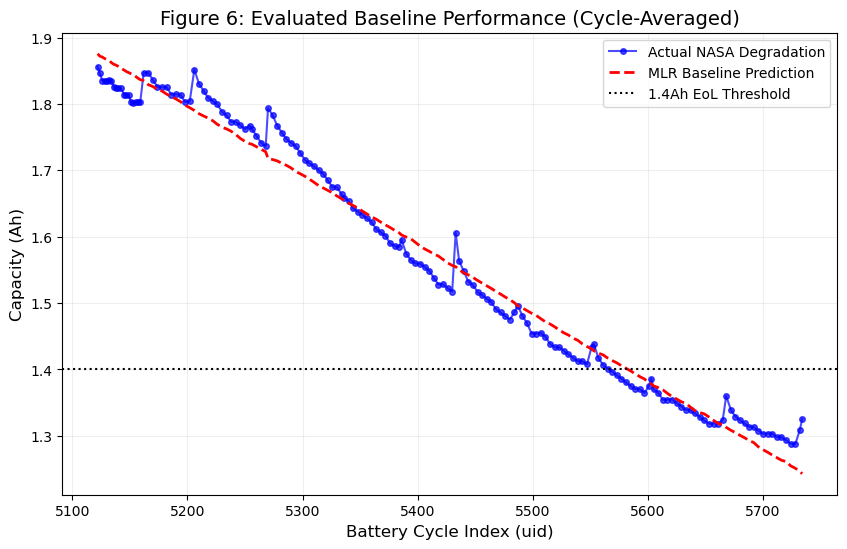

In [15]:
#Figure 6: Evaluated MLR Performance (Knee-point)
# 1. Create a Results DataFrame
# We combine the Test features and the results into one table
results_df = X_test.copy()
results_df['Actual'] = y_test_reg
results_df['Predicted'] = y_pred_mlr

# 2. GROUP BY UID
# find the average capacity for each cycle
chart_data = results_df.groupby('uid').mean().sort_index()

# 3. PLOT THE CLEAN GRAPH
plt.figure(figsize=(10, 6))

# Plotting the Actual Trend
plt.plot(chart_data.index, chart_data['Actual'], label='Actual NASA Degradation', 
         color='blue', marker='o', markersize=4, linewidth=1.5, alpha=0.7)

# Plotting the MLR Prediction
plt.plot(chart_data.index, chart_data['Predicted'], label='MLR Baseline Prediction', 
         color='red', linestyle='--', linewidth=2)

# Adding the Failure Threshold
plt.axhline(y=1.4, color='black', linestyle=':', label='1.4Ah EoL Threshold')

plt.title('Figure 6: Evaluated Baseline Performance (Cycle-Averaged)', fontsize=14)
plt.xlabel('Battery Cycle Index (uid)', fontsize=12)
plt.ylabel('Capacity (Ah)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

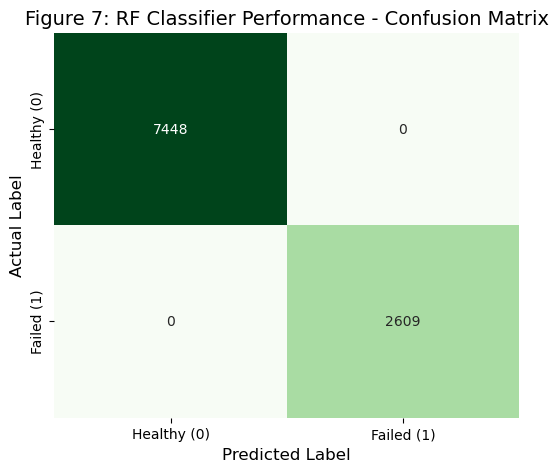

In [16]:
# Figure 7. Random Forest Classifier Performance Confusion Matrix 
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_clf, y_pred_rf)

# Using Seaborn to make a professional heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Healthy (0)', 'Failed (1)'],
            yticklabels=['Healthy (0)', 'Failed (1)'])

plt.title('Figure 7: RF Classifier Performance - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()